In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
#Cast all datatypes

df = pd.read_csv('puut1.csv', 
                 index_col=0,
                 dtype={
                   "length": np.float64,
                   "diameter": np.float64,
                   "cones": np.int64,
                   "leaves": np.int64,
                   "bark_thickness": np.float64,
                   "seed_size": np.float64,
                   "fungi_present": np.bool,
                   "color_guess": np.object_,
                   "soil_pH": np.float64,
                   "collector_id": np.object_,
                   "collector_guess": np.object_,
                   }, 
                   na_values="*"
                   )

In [76]:
#Data preprocessing for missing values and Dataframe shape
print(df.isnull().sum())

length             0
diameter           0
cones              0
leaves             0
bark_thickness     0
seed_size          0
fungi_present      0
color_guess        0
soil_pH            0
collector_id       0
collector_guess    0
dtype: int64


In [77]:
#Sorting columns by their contents

num_variables_columns = ["length", "diameter", "cones", "leaves", "bark_thickness", "seed_size", "soil_pH"]
cat_variables_columns = ["fungi_present", "color_guess"]
y_predicted_columns = ["collector_guess"]
researchers_columns = ["collector_id"]

num_variables = df[num_variables_columns]
cat_variables = df[cat_variables_columns]
y_predicted = df[y_predicted_columns]
researchers = df[researchers_columns]

In [78]:
print(num_variables.describe())

           length    diameter       cones        leaves  bark_thickness  \
count  300.000000  300.000000  300.000000    300.000000       300.00000   
mean   267.447867  115.530267   87.836667  10689.056667         1.15890   
std     78.856833   24.844247   58.511840   5691.384465         0.27241   
min     69.080000   73.960000  -10.000000   1067.000000         0.62000   
25%    207.400000   98.310000   35.750000   5720.000000         0.98000   
50%    289.565000  105.575000   85.500000  10631.000000         1.09000   
75%    306.410000  130.832500  131.250000  15620.500000         1.31000   
max    516.900000  214.820000  199.000000  19956.000000         2.25000   

        seed_size     soil_pH  
count  300.000000  300.000000  
mean     1.000222    7.990200  
std      0.019324    1.040056  
min      0.833844    4.850000  
25%      0.998046    7.320000  
50%      1.000088    8.020000  
75%      1.001857    8.630000  
max      1.158028   11.850000  


Kun numeeristen arvojen ominaisuudet tulostaa describe() komennolla, huomataan muutama epäilyttävä arvo.
1. Käpyjen määrä ei voi olla vähemmän kuin 0
2. Maaperän pH arvolla yli 12 on erittäin harvinainen

Ensimmäinen kohta on luultavasti väärin kirjoitettu, jossa negatiivinen merkki on kirjoitettu vahingossa.
Korjataan tämä muuntamalla kaikki negatiiviset arvot positiivisiksi.

Toinen kohta saattaa olla mahdollinen, joten ei puututa siihen.

In [79]:
df.cones = df.cones.abs()
num_variables = df[num_variables.columns]

print(num_variables.describe())

           length    diameter       cones        leaves  bark_thickness  \
count  300.000000  300.000000  300.000000    300.000000       300.00000   
mean   267.447867  115.530267   88.136667  10689.056667         1.15890   
std     78.856833   24.844247   58.057445   5691.384465         0.27241   
min     69.080000   73.960000    0.000000   1067.000000         0.62000   
25%    207.400000   98.310000   35.750000   5720.000000         0.98000   
50%    289.565000  105.575000   85.500000  10631.000000         1.09000   
75%    306.410000  130.832500  131.250000  15620.500000         1.31000   
max    516.900000  214.820000  199.000000  19956.000000         2.25000   

        seed_size     soil_pH  
count  300.000000  300.000000  
mean     1.000222    7.990200  
std      0.019324    1.040056  
min      0.833844    4.850000  
25%      0.998046    7.320000  
50%      1.000088    8.020000  
75%      1.001857    8.630000  
max      1.158028   11.850000  


In [80]:
print(cat_variables.describe())
print(f'categories of fungi_present: {cat_variables.fungi_present.unique()}')
print(f'categories of color_guess: {cat_variables.color_guess.unique()}')

       fungi_present color_guess
count            300         300
unique             2           5
top            False    lightish
freq             154          76
categories of fungi_present: [False  True]
categories of color_guess: ['dark' 'light' 'mid-green' 'lightish' 'darkish']


In [81]:
print(y_predicted.describe())
print(f'categories of trees: {y_predicted.collector_guess.unique()}')

       collector_guess
count              300
unique               3
top                  2
freq               123
categories of trees: ['1' '2' '3']


In [82]:
print(researchers.describe())
print(f'Number of unique researchers: {researchers.collector_id.unique()}')

       collector_id
count           300
unique            3
top               1
freq            102
Number of unique researchers: ['3' '2' '1']


Luokkamuuttujat vaikuttavat olevan ilman virheellisiä arvoja.

In [83]:
#Arvioidaan numeeristen arvojen jakaumaa normaalijakauman kokeella sekä visuaalisesti boxplotilla
shapiro_test = stats.shapiro(num_variables, axis=0)
for index, row in enumerate(shapiro_test.pvalue):
  print(f'{num_variables.columns[index]:<15} {row:<8.3} {"< 0.05" if row < 0.05  else "> 0.05"}')

length          8.83e-08 < 0.05
diameter        9.83e-15 < 0.05
cones           1.62e-08 < 0.05
leaves          6.92e-09 < 0.05
bark_thickness  4.17e-09 < 0.05
seed_size       3.07e-29 < 0.05
soil_pH         0.37     > 0.05


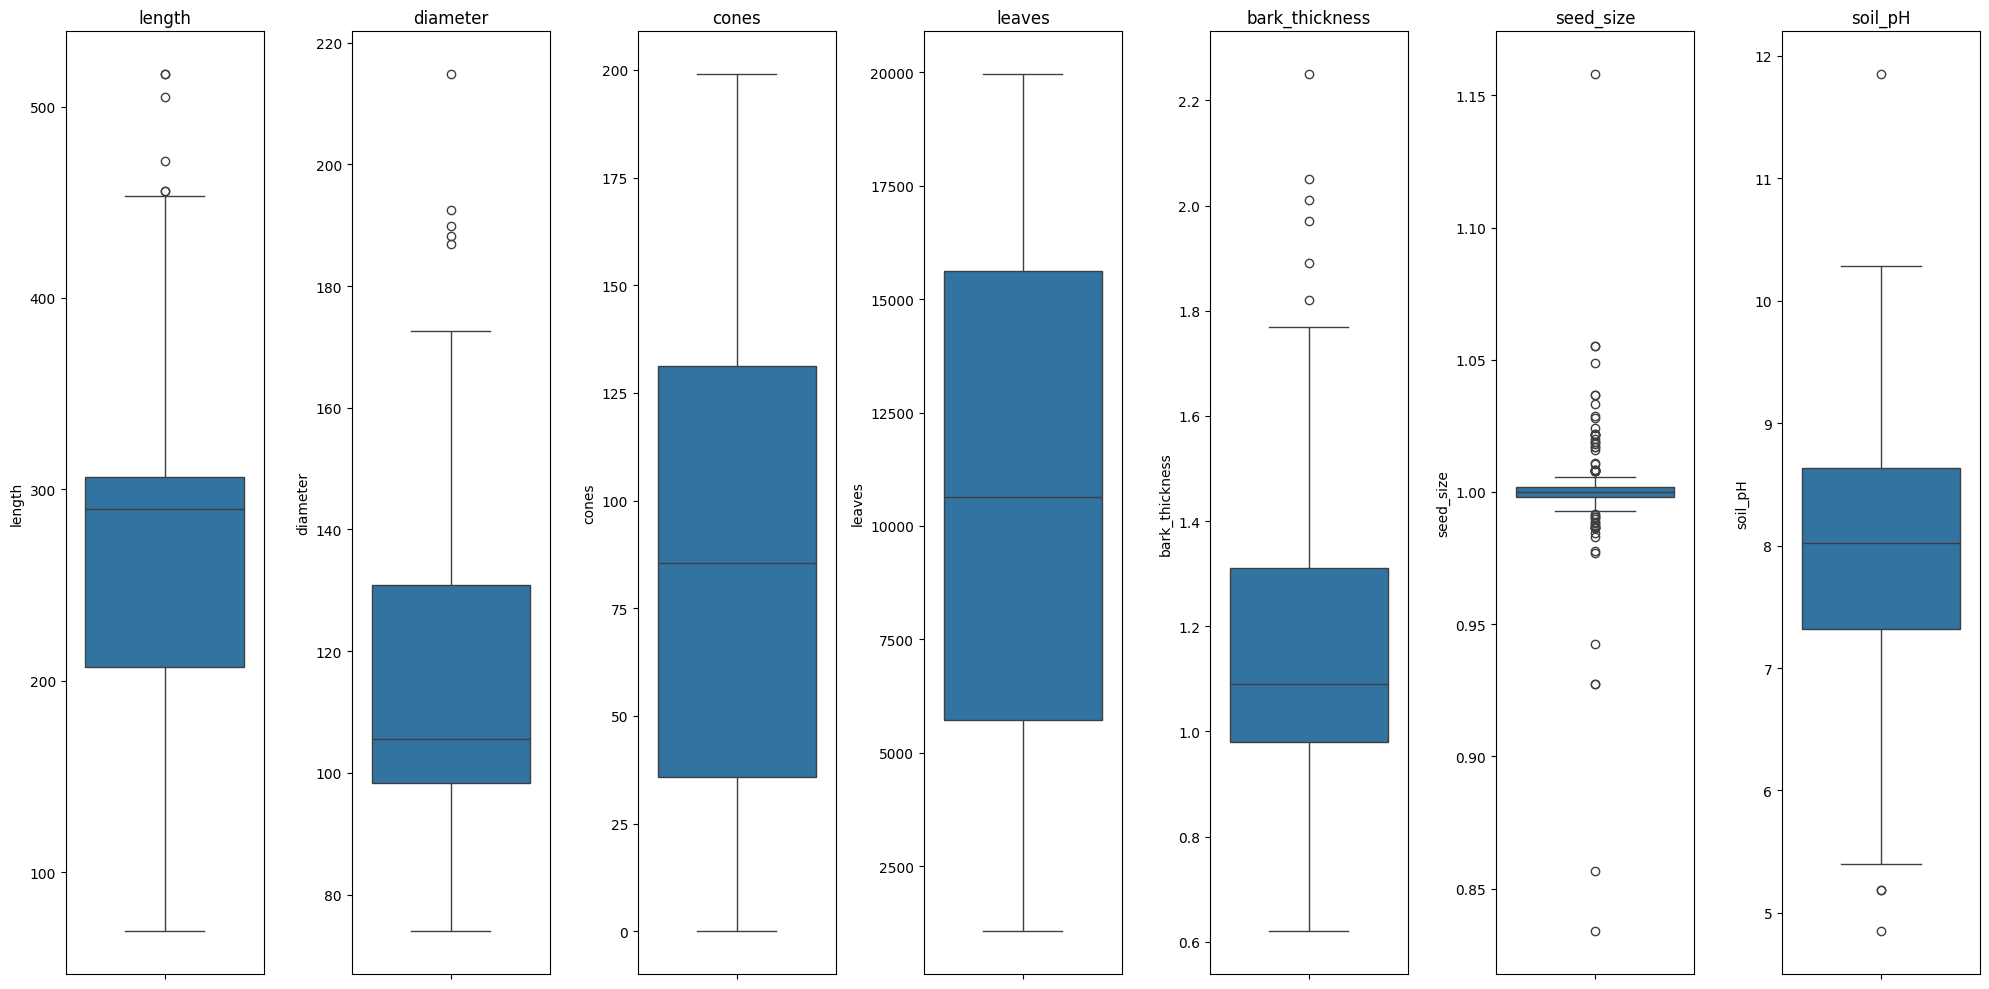

In [84]:
fig, axes = plt.subplots(1, len(num_variables_columns), figsize=(20, 10))

for i, col in enumerate(num_variables_columns):
    sns.boxplot(data=num_variables, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

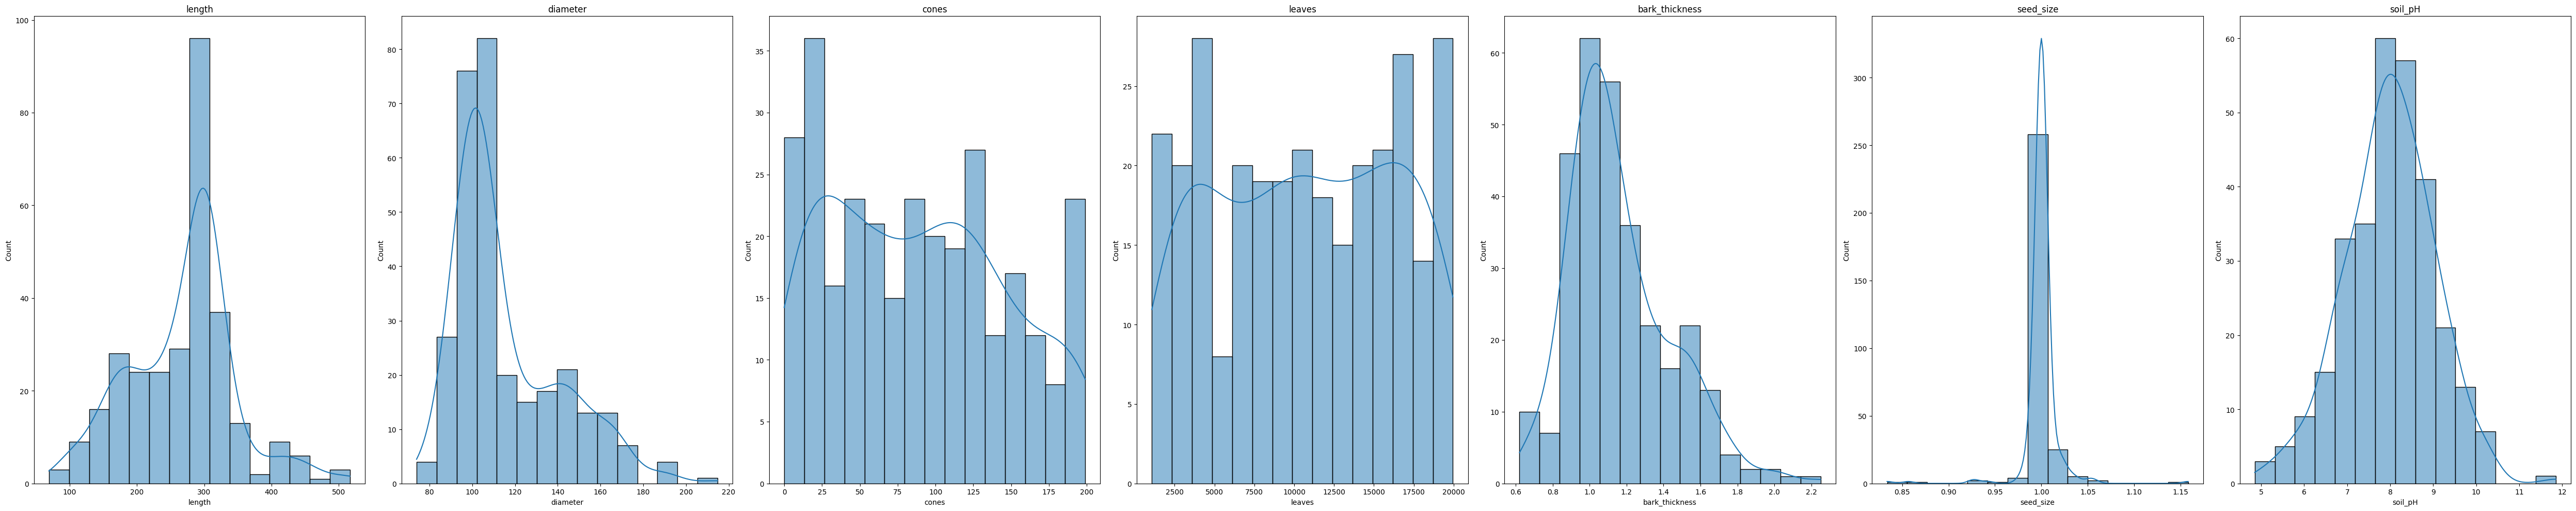

In [85]:
fig, axes = plt.subplots(1, len(num_variables_columns), figsize=(50, 10))

for i, col in enumerate(num_variables_columns):
    sns.histplot(data=num_variables, x=col, ax=axes[i], kde=True, bins=15)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

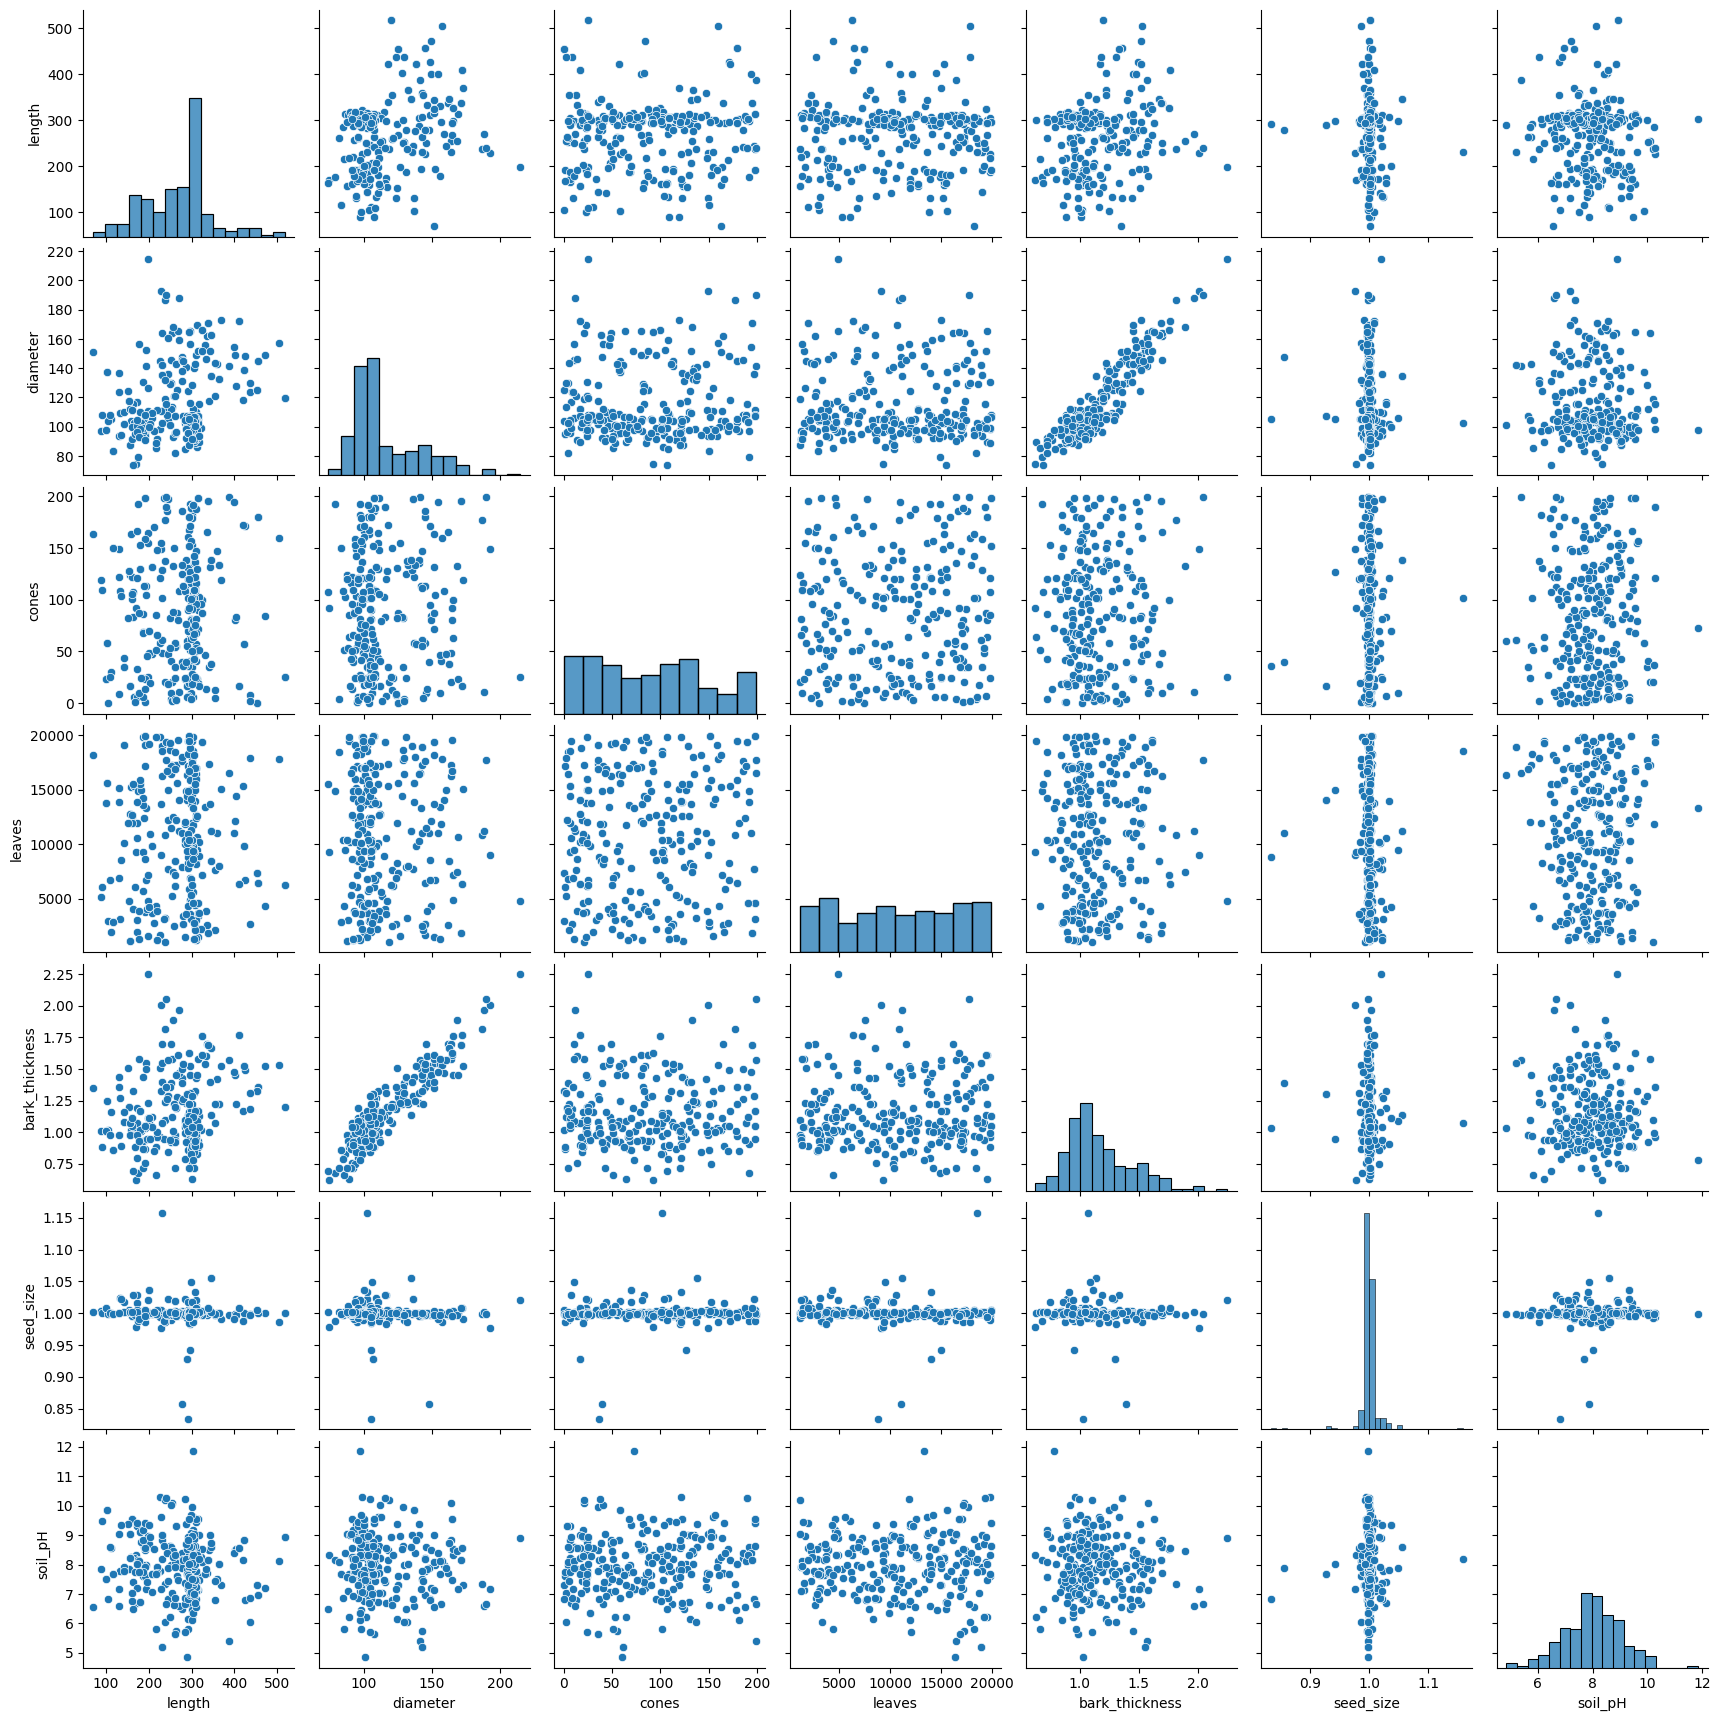

In [86]:
sns.pairplot(data=num_variables)

In [ ]:
df_features = df.drop(['collector_id', 'collector_guess'], axis=1)

In [99]:
scaler = StandardScaler()
df_features[num_variables_columns] = scaler.fit_transform(df[num_variables_columns])

kproto = KPrototypes(n_clusters=3, random_state=42)
cat_index = [df_features.columns.get_loc(c) for c in cat_variables_columns]
clusters = kproto.fit_predict(df_features.values, categorical=cat_index)
df_features['clusters'] = clusters

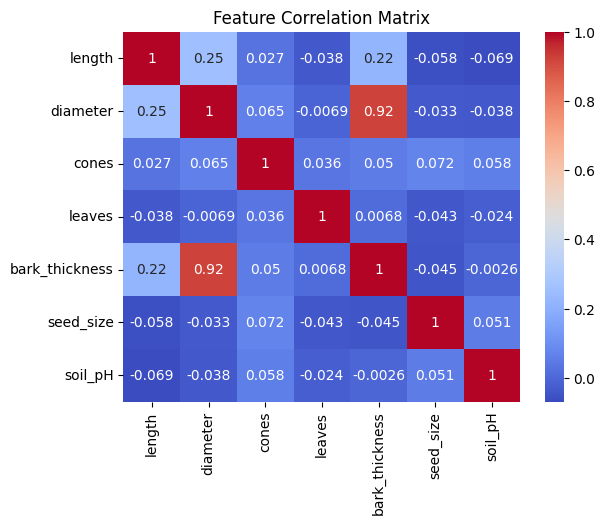

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_features[num_variables_columns].corr()

# Visualize
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Drop features with correlation > 0.85
def drop_correlated(df, threshold=0.85):
    corr = df.corr().abs()
    upper = corr.where(pd.DataFrame(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    ))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop)

df_numeric_filtered = drop_correlated(df_features[num_variables_columns])

In [114]:
print(df_numeric_filtered)

       length  diameter     cones    leaves  bark_thickness  seed_size  \
1   -0.298479  0.816832  1.878230 -0.522723        0.482064   1.110841   
2    0.410696 -1.061987 -0.416432  1.551058       -1.944804   0.007755   
3    2.393413  1.190984  1.584927 -0.745184        0.739459   0.029997   
4   -2.084563  0.873278 -0.519951  0.870299        0.334981   0.031827   
5    0.439784 -0.633810 -1.175569 -1.074300       -0.253350   0.214477   
..        ...       ...       ...       ...             ...        ...   
296  0.498342 -0.598733 -0.209395  1.107720       -0.841682  -0.088919   
297  0.334862  1.986458  0.066654  1.067768        1.732269  -0.204066   
298  0.429495 -0.979335 -0.657976 -0.775808       -0.437204   0.088106   
299  0.895673  2.238446  1.843724 -1.545798        1.952893   0.417037   
300  0.324827 -0.422140  1.584927  1.550706        0.224669  -0.328090   

      soil_pH  
1   -1.127012  
2   -1.714499  
3   -0.992179  
4    1.800792  
5    1.126627  
..        ...  

In [109]:
for col in cat_variables_columns:
    unique_vals = df[col].nunique()
    freq = df[col].value_counts(normalize=True)
    print(f"\n{col}: {unique_vals} unique values")
    print(freq)

# General rules:
# ❌ Drop if only 1 unique value  → no variation
# ❌ Drop if unique values = number of rows → too specific
# ✅ Keep if 2-10 meaningful categories


fungi_present: 2 unique values
fungi_present
False    0.513333
True     0.486667
Name: proportion, dtype: float64

color_guess: 5 unique values
color_guess
lightish     0.253333
mid-green    0.233333
dark         0.203333
light        0.190000
darkish      0.120000
Name: proportion, dtype: float64


In [ ]:
researcher_guess = df_features.join(y_predicted).join(researchers)

In [126]:
print(researcher_guess.dtypes)
print(researcher_guess.head())

length             float64
diameter           float64
cones              float64
leaves             float64
bark_thickness     float64
seed_size          float64
fungi_present         bool
color_guess         object
soil_pH            float64
clusters            uint16
collector_guess     object
collector_id        object
dtype: object
     length  diameter     cones    leaves  bark_thickness  seed_size  \
1 -0.298479  0.816832  1.878230 -0.522723        0.482064   1.110841   
2  0.410696 -1.061987 -0.416432  1.551058       -1.944804   0.007755   
3  2.393413  1.190984  1.584927 -0.745184        0.739459   0.029997   
4 -2.084563  0.873278 -0.519951  0.870299        0.334981   0.031827   
5  0.439784 -0.633810 -1.175569 -1.074300       -0.253350   0.214477   

   fungi_present color_guess   soil_pH  clusters collector_guess collector_id  
1          False        dark -1.127012         2               1            3  
2          False       light -1.714499         0               1     

In [121]:
from sklearn.metrics import accuracy_score, classification_report

In [124]:
# Calculate accuracy for each researcher
researcher_accuracy = researcher_guess.groupby('collector_id').apply(
    lambda x: accuracy_score(x['clusters'], x['collector_guess'])
).reset_index()

researcher_accuracy.columns = ['collector_id', 'accuracy']
researcher_accuracy = researcher_accuracy.sort_values('accuracy', ascending=False)

print(researcher_accuracy)

  collector_id  accuracy
0            1       0.0
1            2       0.0
2            3       0.0
